w: [[ 6.25115739]
 [-7.19860141]
 [10.99824313]]
b: [-6.64494865]
Train_MSE 7.344216077099162
Test MSE 5.4202244570644


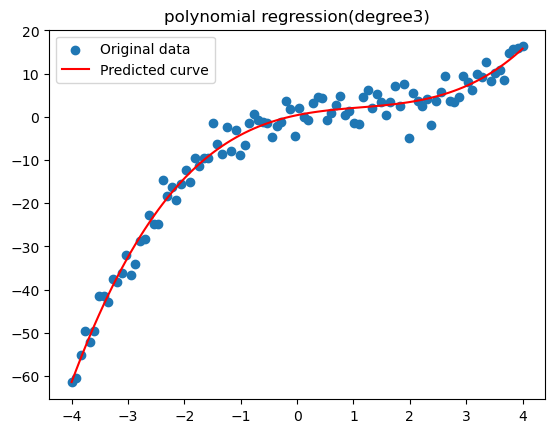

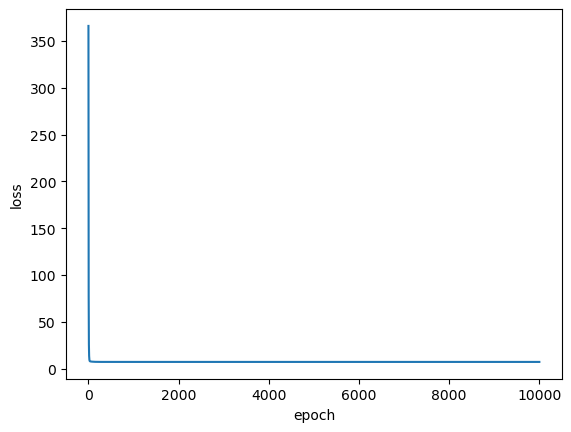

In [47]:
#importing-libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
np.random.seed(42)

# create-nonlinear-data
X = np.linspace(-4, 4, 100)
y = 1 + 2*X - 1.5*X**2 + 0.5*X**3 + np.random.randn(100)*3
y=y.reshape(-1,1)
x=X.reshape(-1,1)

#function-to-convert-into-polynomial-feature
def create_polynomial_features(X,degree):
 X=X.reshape(-1,1)
 features=[X**i for i in range(1,degree+1)]
 X_poly=np.hstack(features)
 return X_poly

#calling-function
degree=3
X_poly=create_polynomial_features(X,degree)

#train-test-split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X_poly,y,test_size=0.2,random_state=42)

#normalize-X_poly
mean=np.mean(x_train,axis=0)
std=np.std(x_train,axis=0)
X_norm_train=(x_train-mean)/std
X_norm_test=(x_test-mean)/std
x_train=np.c_[np.ones(len(X_norm_train)),X_norm_train]
x_test=np.c_[np.ones(len(X_norm_test)),X_norm_test]


#initialize-parameters
w=np.zeros((x_train.shape[1],1))
alpha=0.1
epoch=10000
n=len(y_train)
loss_history=[]

#implement-gradient-descent
for i in range(epoch):
 #y-predict
 y_pred=x_train.dot(w)

 #loss
 MSE=np.mean((y_train-y_pred)**2)
 loss_history.append(MSE)
    
 #compute gradient
 gradient=(-1/n)*x_train.T.dot(y_train-y_pred)
 w=w-alpha*gradient

#result
print("w:",w[1:])
print("b:",w[0])
print("Train_MSE",MSE)

#test-MSE
y_pred_test=x_test.dot(w)
Test_MSE=np.mean((y_test-y_pred_test)**2)
print("Test MSE",Test_MSE)

#plot
x_plot = np.linspace(-4, 4, 100)
x_poly = create_polynomial_features(x_plot, degree)
x_norm = (x_poly - mean) / std   
x_plot_final = np.c_[np.ones(len(x_norm)), x_norm]
y_plot = x_plot_final.dot(w)

plt.scatter(X, y, label="Original data")
plt.plot(x_plot, y_plot, color="red", label="Predicted curve")
plt.title(f"polynomial regression(degree{degree})")
plt.legend()
plt.show()

#plot-loss-curve
plt.plot(loss_history)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

b: [-6.64494865]
w: [[ 6.25115739 -7.19860141 10.99824313]]
Train MSE 7.344216077099162
Test MSE 5.4202244570644


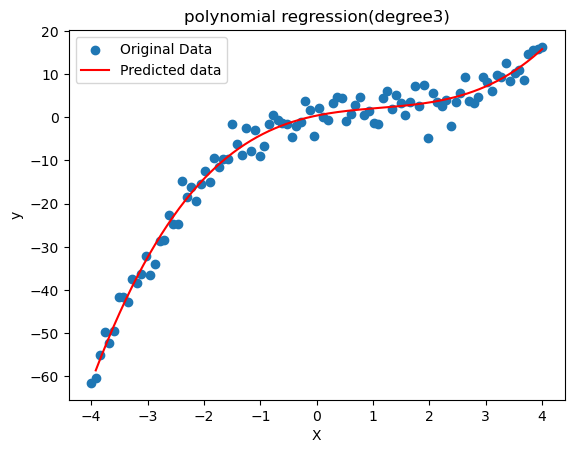

In [48]:
#compare-with-sklearn
#importing-libraries
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

# create-nonlinear-data
X = np.linspace(-4, 4, 100)
y = 1 + 2*X - 1.5*X**2 + 0.5*X**3 + np.random.randn(100)*3
X=X.reshape(-1,1)
y=y.reshape(-1,1)

#train-test-split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#implement-using-sklearn
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
degree=3
model=Pipeline([
    ("poly",PolynomialFeatures(degree,include_bias=False)),
     ("scalar",StandardScaler()),
     ("linreg",LinearRegression())
     ])
model.fit(x_train,y_train)
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)

#inrcepts
print("b:",model.named_steps["linreg"].intercept_)
print("w:",model.named_steps["linreg"].coef_)

#Evaluation
from sklearn.metrics import mean_squared_error
Train_MSE=mean_squared_error(y_train,y_pred_train)
print("Train MSE",Train_MSE)
test_MSE=mean_squared_error(y_test,y_pred_test)
print("Test MSE",Test_MSE)

#plot
 #Create smooth X range
X_range = np.linspace(x_train.min(), x_train.max(), 300).reshape(-1, 1)
# Predict using pipeline
y_range_pred = model.predict(X_range)
# Plot training data
plt.scatter(X,y, label="Original Data")
# Plot polynomial curve
plt.plot(X_range, y_range_pred, color="red", label="Predicted data")
plt.xlabel("X")
plt.ylabel("y")
plt.title(f"polynomial regression(degree{degree})")
plt.legend()
plt.savefig(f"polynomial regression(degree{degree})")
plt.show()



In [49]:

#comparison-table-between-GD-and-sklearn
#GD
w_gd=w[1:]
b_gd=w[0]
Train_MSE_gd=MSE
Test_MSE_gd=Test_MSE   

#sklearn
w_sk=model.named_steps["linreg"].coef_
b_sk=model.named_steps["linreg"].intercept_
Train_MSE_sk=Train_MSE
Test_MSE_sk=test_MSE

coef_gd = w_gd.flatten().tolist()
coef_sk = w_sk.flatten().tolist()

#comparison-table
compare=pd.DataFrame({
    "Model":["Gradient Descent","Sklearn"],
     "Coefficients": [np.round(coef_gd,3), np.round(coef_sk,3)],
    "intercept":[np.round(b_gd,3),np.round(b_sk,3)],
    "Train MSE": [np.round(Train_MSE_gd,3), np.round(Train_MSE_sk,3)],
    "Test MSE": [np.round(Test_MSE_gd,3),np.round(Test_MSE_sk,3)]
})
compare

,Model,Coefficients,intercept,Train MSE,Test MSE
0,Gradient Descent,"[6.251, -7.199, 10.998]",[-6.645],7.344,5.42
1,Sklearn,"[6.251, -7.199, 10.998]",[-6.645],7.344,5.42
